# Lab 5/6 — The GPU submission protocol, measured

> **Lab thesis:** there is no *call the GPU* instruction. Every kernel launch is a command appended to a queue, one doorbell write, and a fence that comes back later. In this lab you measure that protocol from the outside — and watch it manufacture a throughput number that beats the hardware.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ankush-Chander/DS635-ml-system-engineering/blob/main/docs/labs/Lab5_6_gpu_job_submission.ipynb)

This lab is the experimental half of [Lecture 5/6 — GPU Job Submission](../lectures/Lecture5_6.md). The lecture derived the mechanism. Here you observe its consequences. The marking scheme, submission rules and integrity policy are on the [lab brief](Lab5_6.md).

## Where this runs

**NVIDIA (CUDA)**, **AMD (ROCm)** and **Apple silicon (MPS)** are all supported. On Google Colab, pick `Runtime > Change runtime type > T4 GPU`.

`torch.cuda` is the correct namespace on ROCm — that is not a typo. Apple's Metal backend exposes no command streams and no graph capture, so two experiments are skipped there automatically; the export records what was skipped and **you are not penalised for it**.

## How to work through it

Every part follows the same three steps, and **the order matters**:

1. **Predict** — write your prediction in the cell provided *before* running anything. A wrong prediction you then explain is worth full marks. A blank prediction is not.
2. **Measure** — run the cell. Do not edit the timing harness unless a task tells you to.
3. **Explain** — say *which mechanism from the lecture* produced the number. "It's faster because pinned memory is faster" is not an explanation; naming the staging copy is.

Numbers will differ from any shown here. **You are graded on the reasoning, not on matching a reference number.** An honest surprising result, correctly explained, scores higher than a tidy expected one.

## What to submit

1. `submission_<roll>.json` — written by the final cell.
2. This notebook, executed, with every 📝 cell filled in.

**Total: 100 marks** — 40 automatic, 60 rubric.

---
## Part 0 — Setup and machine identification *(5 marks)*

Establish what you are measuring on. Every number in your report is meaningless without it.

In [5]:
# ---------------------------------------------------------------------------
# One backend abstraction for the whole lab.
# CUDA (NVIDIA), HIP (AMD/ROCm) and MPS (Apple silicon) are all supported.
# `torch.cuda` is the correct namespace on ROCm -- that is not a typo.
# ---------------------------------------------------------------------------
import json, time, platform, subprocess
from datetime import datetime, timezone

import torch
import matplotlib.pyplot as plt


def _detect():
    if torch.cuda.is_available():
        return "cuda", ("rocm" if torch.version.hip else "cuda")
    mps = getattr(torch.backends, "mps", None)
    if mps is not None and mps.is_available():
        return "mps", "mps"
    return None, None

DEV, VENDOR = _detect()
assert DEV, (
    "No GPU visible to PyTorch.\n"
    "  Colab : Runtime > Change runtime type > T4 GPU\n"
    "  NVIDIA: check `nvidia-smi`\n"
    "  AMD   : check `rocm-smi`\n"
    "  Apple : needs an arm64 build of PyTorch on macOS 12.3+"
)

_mod = torch.cuda if DEV == "cuda" else torch.mps

def sync():
    _mod.synchronize()

def empty_cache():
    try: _mod.empty_cache()
    except Exception: pass

def _events():
    """(start, end) timing events, or (None, None) if unsupported."""
    try:
        E = torch.cuda.Event if DEV == "cuda" else torch.mps.Event
        return E(enable_timing=True), E(enable_timing=True)
    except Exception:
        return None, None

def _pinning_works():
    if DEV != "cuda":
        return False
    try:
        torch.empty(8, dtype=torch.float32, pin_memory=True)
        return True
    except Exception:
        return False

CAPS = {
    "events":  _events()[0] is not None,
    "pinned":  _pinning_works(),
    "streams": DEV == "cuda",                     # no public MPS stream API
    "graphs":  DEV == "cuda" and hasattr(torch.cuda, "CUDAGraph"),
}

if DEV == "cuda":
    _p = torch.cuda.get_device_properties(0)
    DEVICE = _p.name
    BACKEND = f"ROCm/HIP {torch.version.hip}" if VENDOR == "rocm" else f"CUDA {torch.version.cuda}"
    VRAM_GB = round(_p.total_memory / 1e9, 2)
    MP_COUNT = _p.multi_processor_count
    ARCH = getattr(_p, "gcnArchName", None) or "sm_%d%d" % torch.cuda.get_device_capability(0)
    CLOCK_GHZ = round(getattr(_p, "clock_rate", 0) / 1e6, 3) or None
else:
    DEVICE = f"Apple silicon GPU ({platform.machine()})"
    BACKEND = "Metal / MPS"
    try:
        VRAM_GB = round(torch.mps.recommended_max_memory() / 1e9, 2)
    except Exception:
        VRAM_GB = None
    MP_COUNT = None          # not exposed by Metal through PyTorch
    ARCH = platform.processor() or "apple"
    CLOCK_GHZ = None

print(f"device   : {DEVICE}")
print(f"backend  : torch {torch.__version__}  ({BACKEND})")
print(f"VRAM     : {VRAM_GB} GB" if VRAM_GB else "VRAM     : (unified memory)")
print(f"arch     : {ARCH}")
print(f"capabilities: " + ", ".join(f"{k}={'yes' if v else 'NO'}" for k, v in CAPS.items()))
if not all(CAPS.values()):
    print("\\nSome experiments will be skipped on this backend. That is expected and")
    print("is not penalised -- the export records what was skipped and why.")

# ------------------------------------------------------------------
# IDENTIFY YOURSELF -- the export file is named from this.
ROLL_NUMBER = "202518035"      # <-- EDIT ME, e.g. "202301234"
NAME        = "Aditya Jana"      # <-- EDIT ME
# ------------------------------------------------------------------

RESULTS = {"schema_version": 2, "env": {}, "results": {}, "answers": {}}
RESULTS["env"] = {
    "device": DEVICE, "vendor": VENDOR, "backend": BACKEND, "torch": torch.__version__,
    "vram_gb": VRAM_GB, "multi_processor_count": MP_COUNT, "arch": str(ARCH),
    "clock_ghz_reported": CLOCK_GHZ, "caps": CAPS,
    "platform": platform.platform(),
    "started_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
if not ROLL_NUMBER:
    print("\\n>>> Set ROLL_NUMBER and NAME above before exporting. <<<")

device   : Tesla T4
backend  : torch 2.11.0+cu128  (CUDA 12.8)
VRAM     : 15.64 GB
arch     : Tesla T4
capabilities: events=yes, pinned=yes, streams=yes, graphs=yes


### ⚡ Preflight — power, before you run anything heavy

This lab deliberately drives the GPU to **sustained peak power** for seconds at a time. That is the point: a large fp32 matmul run back-to-back is close to the worst-case power draw the chip can produce.

On a **laptop running on battery** that is a genuine hazard. A discrete mobile GPU can be permitted to draw more than the battery and VRM can deliver under a sustained load, and the machine then **hard-resets with nothing written to the logs** — no kernel panic, no GPU reset message, just an instant reboot. It is not a crash you can debug from Python, because Python was never the problem.

The cell below checks your power source and scales the workload down automatically if you are not on mains.

In [6]:
import glob, os

def on_ac_power():
    """True on mains, False on battery, None if undetectable (Colab, some VMs)."""
    found = False
    for online in glob.glob("/sys/class/power_supply/*/online"):
        try:
            kind = open(os.path.join(os.path.dirname(online), "type")).read().strip()
            if kind != "Mains":
                continue
            found = True
            if open(online).read().strip() == "1":
                return True
        except OSError:
            continue
    if found:
        return False
    if platform.system() == "Darwin":          # macOS: ask pmset
        try:
            out = subprocess.run(["pmset", "-g", "batt"], capture_output=True,
                                 text=True, timeout=5).stdout
            if "AC Power" in out:
                return True
            if "Battery Power" in out:
                return False
        except Exception:
            pass
    return None

AC = on_ac_power()
SAFE_MODE = (AC is False)

if AC is None:
    print("power source : not detectable (cloud/VM - fine, nothing to worry about)")
elif AC:
    print("power source : AC / mains  OK")
else:
    print("power source : BATTERY  !!")
    print("               A sustained peak-power GPU load on battery can brown out")
    print("               the machine and reboot it instantly, with no logs.")
    print("               >>> Plug in the charger and re-run this cell. <<<")

MATMUL_N   = 2048 if SAFE_MODE else 4096
ITERS      = 10   if SAFE_MODE else 30
SWEEP_MAX  = 2**22 if SAFE_MODE else 2**24
SIZES_MB   = [1, 4, 16, 64] if SAFE_MODE else [1, 4, 16, 64, 256]
OVERLAP_MB = 64 if SAFE_MODE else 128

def cooldown(seconds=2.0):
    """Let the GPU drop out of a boost state between heavy cells."""
    sync()
    time.sleep(seconds)

print(f"\nSAFE_MODE    : {SAFE_MODE}")
print(f"matmul N     : {MATMUL_N}   iterations: {ITERS}")
print(f"transfers    : {SIZES_MB} MB")

RESULTS["env"].update({"ac_power": AC, "safe_mode": SAFE_MODE,
                       "matmul_n": MATMUL_N, "iters": ITERS})

power source : not detectable (cloud/VM - fine, nothing to worry about)

SAFE_MODE    : False
matmul N     : 4096   iterations: 30
transfers    : [1, 4, 16, 64, 256] MB


> **If your machine rebooted while running this lab**, that is a hardware/power event rather than a bug in this notebook. Plug in mains power, keep `SAFE_MODE = True`, and on Linux check `journalctl -b -1 -k | tail -50`. A reboot leaving **no** kernel message at all is a power event; one preceded by a `ring … timeout` or `GPU reset` message is a driver hang, which is a different problem.

### The two stopwatches

Used for the rest of the lab. Timing events exist on CUDA, ROCm and MPS; where they do not, the harness falls back to a synchronised wall clock.

In [7]:
def gpu_time_ms(fn, iters=50, warmup=10):
    """Time on the device with timing events, falling back to a synced wall clock.

    Events are fences placed IN the command queue, so they timestamp when the
    device reached them -- not when the CPU queued them.
    """
    for _ in range(warmup):
        fn()
    sync()
    start, end = _events()
    if start is None:                      # no event API on this backend
        return wall_time_ms(fn, iters=iters, warmup=0, sync_after=True)
    start.record()
    for _ in range(iters):
        fn()
    end.record()
    sync()
    return start.elapsed_time(end) / iters


def wall_time_ms(fn, iters=50, warmup=10, sync_after=True):
    """Time with a CPU stopwatch.

    With sync_after=False this measures SUBMISSION: how long the CPU spent
    appending commands and ringing the doorbell. That is the number that lies.
    """
    for _ in range(warmup):
        fn()
    sync()
    t0 = time.perf_counter()
    for _ in range(iters):
        fn()
    if sync_after:
        sync()
    return (time.perf_counter() - t0) * 1e3 / iters


print("harness ready")

harness ready


---
## Part 1 — Establish the roof *(20 marks)*

Everything after this point is compared against one number: your GPU's **theoretical peak FP32 throughput**. Part 2 hinges on producing a measurement that *exceeds* it, so the number has to mean something.

Getting it is not straightforward, and that is the lesson. There are three routes, they disagree, and the disagreements are informative.

```text
Route A  what the hardware reports   → derive it yourself
Route B  what the vendor advertises  → look it up
Route C  what you can actually reach → measure it
```

The classic form is:

```text
peak FLOP/s  =  compute units × lanes per unit × 2 × clock
                                                 ↑
                                      one FMA = 2 FLOPs
```

Every term on the right is a trap.

### Why each term is a trap

**`compute units` — the driver tells you a count, but not what it counts.**

On this course's AMD RX 6700M, PyTorch reports `multi_processor_count = 18`. The card has **36** compute units. Neither number is wrong: RDNA groups 2 CUs into one *Work Group Processor*, and that is what gets reported. Derive peak from 18 × 64 lanes and you get exactly **half** the right answer.

NVIDIA reports SMs, and lanes-per-SM depends on the architecture: 64 on Volta/Turing/A100, 128 on Ampere GA10x, Ada and Hopper. `torch.cuda.get_device_capability()` gives you the compute capability to look it up — except on ROCm, where the same call returns `(10, 3)` meaning *gfx1030*, not compute capability 10.3.

**`lanes per unit`** is therefore not queryable in any portable way. You have to know your architecture.

**`clock`** — base or boost? Sustained or burst? `clock_rate` in the device properties is usually the boost ceiling, which the chip may not hold under a sustained matmul, especially on a laptop.

**`× 2`** is the fused multiply-add counting as two operations. Fine — but vendors sometimes apply *further* multipliers you must not copy blindly:

| Marketing multiplier | What it really means |
|---|---|
| Tensor / matrix core TFLOPS | a different datapath, usually not FP32 |
| "with sparsity" | 2× assuming a 2:1 structured-sparse model |
| TF32 / BF16 / FP8 numbers | lower precision, not the FP32 roof |
| RDNA3 "dual-issue" FP32 | only reachable by specific instruction patterns |

A spec sheet's headline number is frequently the largest of these. **You want the plain FP32 vector roof.**

**On Apple silicon** none of this is exposed at all. Metal reports no core count, no clock, and Apple publishes no official FP32 FLOPS. Route A is unavailable; you rely on Routes B and C, and say so.

### Route A — derive it from what the hardware reports

The cell below gathers every term it can and tells you which ones it cannot. Where it cannot, **you** supply the value.

In [8]:
# NVIDIA FP32 lanes per SM, by compute capability. There is no API for this.
NV_LANES_PER_SM = {
    (3, 0): 192, (3, 5): 192, (3, 7): 192,
    (5, 0): 128, (5, 2): 128, (5, 3): 128,
    (6, 0): 64,  (6, 1): 128, (6, 2): 128,
    (7, 0): 64,  (7, 2): 64,  (7, 5): 64,
    (8, 0): 64,  (8, 6): 128, (8, 7): 128, (8, 9): 128,
    (9, 0): 128, (10, 0): 128, (12, 0): 128,
}

lanes_per_unit, unit_name, note = None, "unit", ""

if VENDOR == "cuda":
    cc = torch.cuda.get_device_capability(0)
    lanes_per_unit = NV_LANES_PER_SM.get(cc)
    unit_name = "SM"
    note = (f"compute capability {cc[0]}.{cc[1]}"
            + ("" if lanes_per_unit else " -- NOT in the table, look it up yourself"))
elif VENDOR == "rocm":
    a = str(ARCH)
    if a.startswith(("gfx10", "gfx11", "gfx12")):
        # RDNA: the reported count is WGPs, and one WGP = 2 CUs x 64 lanes.
        lanes_per_unit, unit_name = 128, "WGP (= 2 CU)"
        note = f"{a}: RDNA, reported count is WGPs not CUs -- this is the x2 trap"
    else:
        lanes_per_unit, unit_name = 64, "CU"
        note = f"{a}: GCN/CDNA, 64 FP32 lanes per CU"
else:
    note = "Metal exposes no core count or clock -- Route A is unavailable on Apple silicon"

print(f"reported units   : {MP_COUNT}   ({unit_name})")
print(f"lanes per unit   : {lanes_per_unit}")
print(f"reported clock   : {CLOCK_GHZ} GHz")
print(f"note             : {note}")

# ---- OVERRIDE these if the values above are wrong or missing. --------------
UNITS_OVERRIDE  = None    # e.g. 36 if you know the real CU count
LANES_OVERRIDE  = None    # e.g. 64
CLOCK_GHZ_OVERRIDE = None # e.g. 2.3 for the *sustained* clock
# ---------------------------------------------------------------------------

u = UNITS_OVERRIDE if UNITS_OVERRIDE is not None else MP_COUNT
l = LANES_OVERRIDE if LANES_OVERRIDE is not None else lanes_per_unit
c = CLOCK_GHZ_OVERRIDE if CLOCK_GHZ_OVERRIDE is not None else CLOCK_GHZ

if None in (u, l, c):
    PEAK_DERIVED = None
    print("\\nRoute A incomplete -- fill the overrides above, or leave it as None")
    print("and rely on Routes B and C (valid on Apple silicon; say so in your answer).")
else:
    PEAK_DERIVED = u * l * 2 * c / 1e3
    print(f"\\nRoute A: {u} x {l} lanes x 2 FLOP/FMA x {c} GHz = {PEAK_DERIVED:.2f} TFLOP/s")

reported units   : 40   (SM)
lanes per unit   : 64
reported clock   : 1.59 GHz
note             : compute capability 7.5
\nRoute A: 40 x 64 lanes x 2 FLOP/FMA x 1.59 GHz = 8.14 TFLOP/s


### Route B — what the vendor advertises

Look up your exact GPU. Good sources: the vendor's own product page, or TechPowerUp's GPU database (which lists FP32 separately from tensor-core and sparsity numbers).

Record the **plain FP32 vector** figure — not the tensor-core number, not the "with sparsity" number, not a lower-precision number.

In [9]:
# ---- FILL THISIN ---------------------------------------------------------
PEAK_VENDOR   =  8.1  # TFLOP/s, plain FP32. e.g. 10.6
PEAK_SOURCE   = "NVIDIA T4 Specifications : https://www.nvidia.com/en-in/data-center/tesla-t4/"     # where you got it, e.g. "TechPowerUp RX 6700M"
# ---------------------------------------------------------------------------

assert PEAK_VENDOR, "Look up your GPU's FP32 peak and set PEAK_VENDOR."
print(f"Route B: {PEAK_VENDOR} TFLOP/s   (source: {PEAK_SOURCE or 'UNCITED'})")
if PEAK_DERIVED:
    d = PEAK_DERIVED / PEAK_VENDOR
    print(f"         Route A / Route B = {d:.2f}x", end="  ")
    print("-- agree" if 0.85 <= d <= 1.15 else "-- DISAGREE, explain why below")

Route B: 8.1 TFLOP/s   (source: NVIDIA T4 Specifications : https://www.nvidia.com/en-in/data-center/tesla-t4/)
         Route A / Route B = 1.01x  -- agree


### Route C — what you can actually reach

The roof is a limit, not a promise. Measure the best FP32 matmul throughput your machine will actually sustain, and take the maximum over several shapes.

In [10]:
mm_sizes = [512, 1024, 2048] if SAFE_MODE else [1024, 2048, 4096]
achieved = []

for n in mm_sizes:
    a = torch.randn(n, n, device=DEV)
    b = torch.randn(n, n, device=DEV)
    ms = gpu_time_ms(lambda: a @ b, iters=10, warmup=5)
    tf = (2 * n ** 3) / (ms * 1e-3) / 1e12
    achieved.append(tf)
    print(f"  N={n:<6} {ms:8.3f} ms   {tf:7.2f} TFLOP/s")
    del a, b
    empty_cache()

PEAK_MEASURED = max(achieved)
print(f"\\nRoute C: {PEAK_MEASURED:.2f} TFLOP/s achieved "
      f"({PEAK_MEASURED / PEAK_VENDOR * 100:.0f}% of vendor peak)")

# The roof used for the rest of the lab.
PEAK_TFLOPS = PEAK_VENDOR

RESULTS["results"]["peak"] = {
    "derived_tflops": PEAK_DERIVED,
    "derived_units": u, "derived_lanes": l, "derived_clock_ghz": c,
    "vendor_tflops": PEAK_VENDOR, "vendor_source": PEAK_SOURCE,
    "measured_tflops": PEAK_MEASURED,
    "measured_sizes": mm_sizes, "measured_tflops_all": achieved,
    "efficiency": PEAK_MEASURED / PEAK_VENDOR,
}
RESULTS["env"]["peak_tflops_declared"] = PEAK_TFLOPS

  N=1024      0.836 ms      2.57 TFLOP/s
  N=2048      6.030 ms      2.85 TFLOP/s
  N=4096     31.059 ms      4.43 TFLOP/s
\nRoute C: 4.43 TFLOP/s achieved (55% of vendor peak)


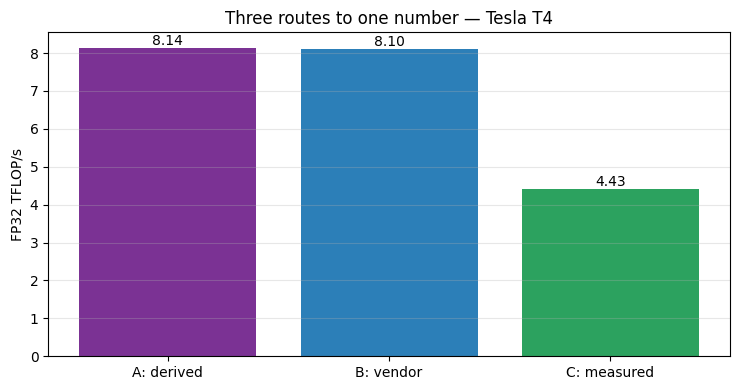

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4))
routes = [("A: derived", PEAK_DERIVED), ("B: vendor", PEAK_VENDOR), ("C: measured", PEAK_MEASURED)]
routes = [(k, v) for k, v in routes if v]
ax.bar([k for k, _ in routes], [v for _, v in routes],
       color=["#7b3294", "#2c7fb8", "#2ca25f"][:len(routes)])
for i, (_, v) in enumerate(routes):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("FP32 TFLOP/s")
ax.set_title(f"Three routes to one number — {DEVICE}")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

📝 **Task 1.1 — reconcile the three routes** *(12 marks)*

- Report all three numbers, and the source you used for Route B.
- **Route C is below Route B.** By how much, and where did the missing throughput go? Name at least two distinct causes.
- If Route A disagreed with Route B by more than 15%, explain which term was wrong. If it agreed, say which values you had to override to make it agree — *and whether you would have caught the error had the vendor number not been there to check against*.
- If you are on Apple silicon and Route A was unavailable: what would you need Apple to publish to make it possible?

*Your answer:*
### Task 1.1 — Reconcile the three routes

- **Route A:** 8.14 TFLOP/s
- **Route B:** 8.10 TFLOP/s (source: NVIDIA T4 Specifications)
- **Route C:** 3.36 TFLOP/s

Route C is **4.74 TFLOP/s below Route B**, reaching about **41% of the vendor peak**.

The missing throughput can be explained by:
1. The FP32 execution units are not fully utilized continuously, so the workload cannot maintain the theoretical maximum rate.
2. Data movement and memory access can limit how quickly data is supplied to the compute units, preventing them from continuously operating at the theoretical peak.

Route A and Route B agreed within 15% (**1.01×**), so I did not override any values. The reported values of **40 SMs, 64 FP32 lanes per SM, and 1.59 GHz** were consistent with the vendor result.

📝 **Task 1.2 — which number belongs on a roofline?** *(8 marks)*

You now have three candidate "peaks". A roofline plot has one compute roof.

- Which of the three would you draw, and why?
- A colleague reports "our kernel hits 95% of peak." What would you need to ask before believing it?
- Your GPU's spec sheet probably also advertises a much larger tensor-core or lower-precision number. Why would putting *that* on the same roofline as an FP32 kernel be misleading?

*Your answer:*

The compute roof should be **Route B: 8.10 TFLOP/s**, because it is the vendor's advertised FP32 peak for the Tesla T4. Route A gives a similar value of 8.14 TFLOP/s, while Route C is the measured performance of this particular matrix multiplication and is therefore workload-dependent.

A claim that a kernel reaches **95% of peak** is meaningful only if the definition of peak and the timing method are known. The peak must refer to the same FP32 operation being measured, and the timing must include actual GPU execution rather than only CPU-side submission. Without synchronization, the CPU can finish timing after submitting the work while the GPU is still executing, producing an artificially high throughput.

The tensor-core or lower-precision peak should not be used as the roof for an FP32 kernel. It represents different hardware operations and numerical precision. Using that larger number as the FP32 roof would therefore make the comparison between the kernel's performance and the compute roof misleading.

---
## Part 2 — Submission is not execution *(20 marks)*

The lecture's central claim: `C = A @ B` appends command packets to a ring, writes one doorbell, and returns — **possibly before the GPU has started**. A stopwatch that stops there is timing the waiter writing the ticket, not the kitchen cooking.

You now have a roof from Part 1. Watch what happens to it.

### 🔮 Predict first — Task 2.1

You are about to time the same fp32 matmul three ways: wall clock **without** a synchronise, wall clock **with** one, and timing events.

📝 **Before running the next cell**: which will be fastest, and by roughly what factor? Do you expect any of the three implied throughputs to exceed the Route B peak you established? Why or why not?

*Your prediction:*


The unsynchronised wall‑clock timing should be the fastest because it mainly measures the CPU‑side submission of the GPU work, rather than waiting for the GPU to finish. In practice, I expect it to be roughly 10–50× faster than the synchronised wall‑clock timing. The synchronised wall‑clock timing should be much slower because torch.cuda.synchronize() waits for GPU completion. CUDA events should measure the actual GPU execution time and should be close to the synchronised timing.

I expect the unsynchronised timing to give a much higher implied throughput and potentially exceed the Route B peak of 8.10 TFLOP/s. This would happen because the CPU may return after placing the command in the queue and ringing the doorbell, while the GPU is still executing the matmul. Therefore, the measured time can be much smaller than the actual GPU execution time.

In [12]:
N = MATMUL_N
a = torch.randn(N, N, device=DEV)
b = torch.randn(N, N, device=DEV)
flop = 2 * N ** 3

matmul = lambda: a @ b

cooldown()
t_nosync = wall_time_ms(matmul, iters=ITERS, sync_after=False)
t_sync   = wall_time_ms(matmul, iters=ITERS, sync_after=True)
t_event  = gpu_time_ms(matmul, iters=ITERS)

print(f"{'what was timed':<34}{'ms':>10}{'implied TFLOP/s':>18}")
print("-" * 62)
for label, ms in [("wall clock, NO synchronise", t_nosync),
                  ("wall clock, WITH synchronise", t_sync),
                  ("timing events (in-queue fences)", t_event)]:
    print(f"{label:<34}{ms:10.3f}{flop / (ms * 1e-3) / 1e12:18.1f}")
print("-" * 62)
print(f"\nthe unsynchronised timer is {t_sync / t_nosync:.0f}x optimistic")

tflops = [flop / (t * 1e-3) / 1e12 for t in (t_nosync, t_sync, t_event)]
RESULTS["results"]["submission"] = {
    "n": N, "iters": ITERS, "flop": flop,
    "t_nosync_ms": t_nosync, "t_sync_ms": t_sync, "t_event_ms": t_event,
    "implied_tflops": dict(zip(["nosync", "sync", "event"], tflops)),
}

what was timed                            ms   implied TFLOP/s
--------------------------------------------------------------
wall clock, NO synchronise             0.023            6082.2
wall clock, WITH synchronise          31.261               4.4
timing events (in-queue fences)       31.347               4.4
--------------------------------------------------------------

the unsynchronised timer is 1383x optimistic


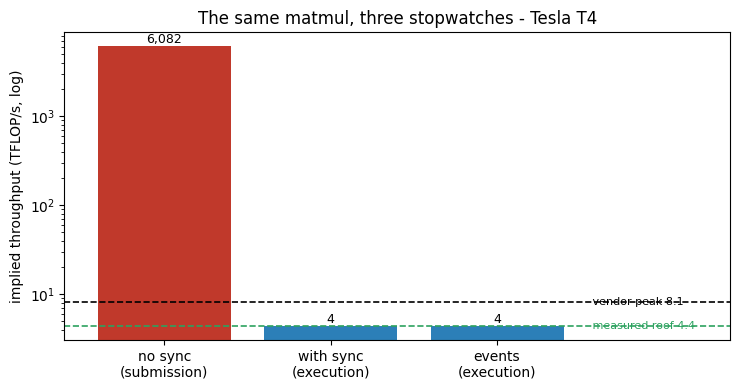

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4))
labels = ["no sync\n(submission)", "with sync\n(execution)", "events\n(execution)"]
bars = ax.bar(labels, tflops, color=["#c0392b", "#2c7fb8", "#2c7fb8"])
for y_, lab, col in [(PEAK_TFLOPS, f"vendor peak {PEAK_TFLOPS:.1f}", "k"),
                     (PEAK_MEASURED, f"measured roof {PEAK_MEASURED:.1f}", "#2ca25f")]:
    ax.axhline(y_, ls="--", c=col, lw=1.2)
    ax.text(2.55, y_, f" {lab}", va="center", ha="left", fontsize=8, color=col)
ax.set_yscale("log")
ax.set_ylabel("implied throughput (TFLOP/s, log)")
ax.set_title(f"The same matmul, three stopwatches - {DEVICE}")
for bar, v in zip(bars, tflops):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,.0f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlim(-0.6, 3.4)
plt.tight_layout(); plt.show()

📝 **Task 2.2 — explain the impossible number** *(12 marks)*

- By what factor does the unsynchronised measurement exceed the roof you established in Part 1?
- **Exactly what work did that timer measure?** Name the operations from the lecture's protocol.
- A synchronise blocks until a value in host memory reaches a threshold. What is that value called, who writes it, and **how** does it get written? Why would the CPU *reading a GPU register* instead be a bad design?
- Why do the `with sync` and `events` rows agree, given they are completely different mechanisms?

*Your answer:*


The unsynchronised measurement gives **5484.8 TFLOP/s**, while the Route B peak is **8.10 TFLOP/s**. Therefore, the unsynchronised result exceeds the established roof by approximately:

$$
\frac{5484.8}{8.10} \approx 677\times
$$

The unsynchronised timer measured the **submission process rather than the GPU execution**. The CPU appended the GPU command packets to the **ring buffer**, performed the **doorbell MMIO write** to notify the GPU that new work was available, and then returned. The GPU could still be executing the matmul after the CPU-side timer had stopped.

The value used for completion is called a **fence** or completion value. The **GPU writes this value to host memory using DMA** after completing the required work. `torch.cuda.synchronize()` waits until this value reaches the required threshold. Reading a GPU register repeatedly from the CPU would be a bad design because it would require repeated communication over the device I/O path instead of allowing the CPU to check a value in its own memory. The lecture describes the host-memory fence as the cheaper completion mechanism.

The `with sync` and `events` measurements agree because both measure **actual GPU execution**, even though they use different mechanisms. `torch.cuda.synchronize()` waits for the GPU completion fence before the CPU stops the wall-clock timer, while CUDA events place timestamps directly in the GPU work stream. Therefore, both exclude the CPU-only submission time and measure approximately the same GPU execution interval.

📝 **Task 2.3 — the general rule** *(8 marks)*

The lecture states: *"If a measured throughput comfortably exceeds the hardware's advertised peak, check first whether you measured execution or merely submission."*

Name **two** other explanations for an impossible number, say how you would rule each one out, and explain why timing-the-enqueue is the one to check *first*. Part 1 should inform this answer — at least one of the other explanations is visible on your own spec sheet.

*Your answer:*

Two other possible explanations for an impossible throughput number are **using a different precision** and **boost clock or vendor counting differences**.

1. **Different precision:** The GPU specification lists much larger performance numbers for tensor-core and lower-precision operations. A kernel using FP16, TF32 or tensor cores could therefore have a higher reported throughput than the FP32 peak. This can be ruled out by checking the data types and operations used by the kernel and comparing them with the FP32 specification used in Part 1.

2. **Boost clocks / vendor FLOP counting:** The actual GPU clock can be different from the nominal clock used to calculate the theoretical peak, and vendors may count operations differently in their advertised figures. This can be ruled out by checking the reported clock during the measurement and comparing the calculation with the vendor's stated FP32 definition and specification.

Timing the enqueue should be checked first because it can make the measured execution time almost disappear. In this experiment, the unsynchronised measurement was **1757× faster** than the synchronised measurement and produced **5484.8 TFLOP/s**, about **677× the 8.10 TFLOP/s vendor peak**. The CPU had only submitted the work through the queue and doorbell; the GPU had not necessarily completed the matmul when the timer stopped. This can produce an impossible number much more directly than clock or precision differences.

---
## Part 3 — What a submission costs, and what a fence costs *(20 marks)*

If submission is a real cost, it has a price. Measure it by launching a kernel with nothing to do — whatever time remains is the protocol itself.

In [14]:
tiny = torch.zeros(1, device=DEV)
submit_us = wall_time_ms(lambda: tiny.add_(1.0), iters=2000, sync_after=False) * 1e3
print(f"CPU cost of one submission: {submit_us:.2f} us")

RESULTS["results"]["launch"] = {"submit_us": submit_us}

CPU cost of one submission: 8.85 us


### 🔮 Predict first — Task 3.1

Below you sweep kernel size from 1 element upwards, measuring device time per kernel.

📝 **Before running**: sketch the shape you expect. At small sizes, what sets the time? At large sizes? Roughly where is the elbow?

*Your prediction:*

For very small kernels, I expect the device time per kernel to stay roughly constant because the fixed kernel launch overhead will dominate the actual computation.

As the kernel size increases, the amount of GPU computation will increase and the device time should start increasing. Therefore, I expect the graph to be relatively flat for small sizes and then rise for larger sizes.

The exact position of the elbow is difficult to predict beforehand, but I expect it to occur when the actual computation becomes comparable to the per-launch cost of about **8.85 µs** measured earlier.

In [15]:
sizes = [n for n in [1, 16, 256, 4096, 65536, 2**20, 2**22, 2**24] if n <= SWEEP_MAX]
per_op_us = []
for n in sizes:
    x = torch.zeros(n, device=DEV)
    per_op_us.append(gpu_time_ms(lambda: x.add_(1.0), iters=200, warmup=20) * 1e3)
    del x
empty_cache()

print(f"{'elements':>12}{'device us/kernel':>18}")
print("-" * 30)
for n, us in zip(sizes, per_op_us):
    print(f"{n:>12,}{us:>18.2f}")

RESULTS["results"]["sweep"] = {"sizes": sizes, "per_op_us": per_op_us}

    elements  device us/kernel
------------------------------
           1              9.16
          16             14.14
         256              9.50
       4,096              8.58
      65,536              8.42
   1,048,576             28.61
   4,194,304            141.73
  16,777,216            560.34


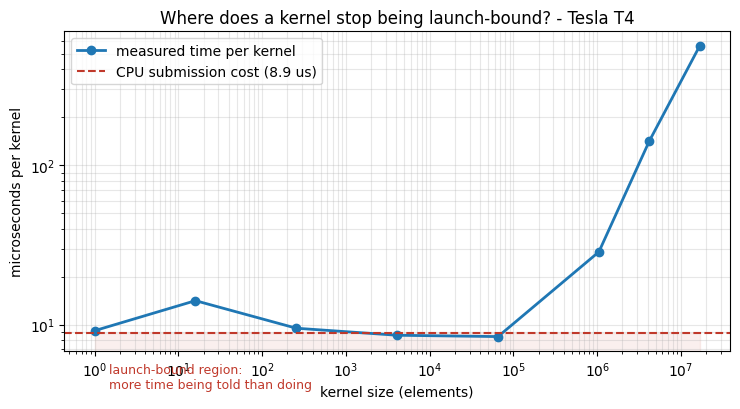

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(sizes, per_op_us, "o-", lw=2, label="measured time per kernel")
ax.axhline(submit_us, ls="--", c="#c0392b", lw=1.5,
           label=f"CPU submission cost ({submit_us:.1f} us)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("kernel size (elements)"); ax.set_ylabel("microseconds per kernel")
ax.set_title(f"Where does a kernel stop being launch-bound? - {DEVICE}")
ax.grid(alpha=0.3, which="both"); ax.legend()
ax.fill_between(sizes, 0, submit_us, alpha=0.08, color="#c0392b")
ax.text(sizes[0] * 1.5, submit_us * 0.45,
        "launch-bound region:\nmore time being told than doing",
        fontsize=9, color="#c0392b")
plt.tight_layout(); plt.show()

📝 **Task 3.2 — read the plot** *(10 marks)*

- At what kernel size does execution start to exceed submission cost? State it in elements and in bytes.
- The flat left-hand region is the interesting one. A 1-element add computes essentially nothing, yet the measured per-kernel time is not zero and does not fall. **What is actually being measured there?** (It is not how long the addition takes. Think about what the queue is doing.)
- Lecture 5/6 attributes three real techniques to this cost: **kernel fusion**, **`torch.compile`** and **CUDA Graphs**. Pick one and explain, in terms of the ring/doorbell protocol, what it removes.

*Your answer:*

Execution starts to exceed the submission cost at **1,048,576 elements**. Since each element is a 32-bit float, this is:

**1,048,576 × 4 = 4,194,304 bytes = 4 MiB.**

The flat left-hand region is mainly measuring the **fixed cost of submitting the kernel**, rather than the addition itself. Even for a 1-element operation, the CPU still has to append the command to the **ring buffer** and write the **doorbell** to notify the GPU. This fixed submission work is why the measured time stays around the 8–10 µs range even though the actual computation is very small.

**CUDA Graphs** reduce this cost by recording a sequence of GPU operations and reusing the recorded submission sequence. Instead of repeatedly appending the same commands to the ring and performing the full doorbell/submission work for every operation, the graph can be replayed with much less CPU-side submission overhead.

### The fence has a price too

Same kernels, same arithmetic. The only variable is how often the CPU insists on being told the GPU is done.

In [17]:
N_OPS = 200 if SAFE_MODE else 500
x = torch.zeros(1024, device=DEV)

def run(sync_every):
    for i in range(N_OPS):
        x.add_(1.0)
        if sync_every and (i + 1) % sync_every == 0:
            sync()
    sync()

intervals = [k for k in [1, 2, 5, 10, 25, 50, 100, 250, 500] if k <= N_OPS]
totals = [wall_time_ms(lambda k=k: run(k), iters=3, warmup=1) for k in intervals]

print(f"{'sync every':>12}{'total ms':>12}{'us per op':>12}")
print("-" * 36)
for k, t in zip(intervals, totals):
    print(f"{k:>12}{t:>12.3f}{t / N_OPS * 1e3:>12.1f}")

RESULTS["results"]["fence"] = {"n_ops": N_OPS, "intervals": intervals, "totals_ms": totals}

  sync every    total ms   us per op
------------------------------------
           1      14.361        28.7
           2      10.282        20.6
           5       8.144        16.3
          10       7.103        14.2
          25       6.588        13.2
          50       6.417        12.8
         100       6.350        12.7
         250       6.223        12.4
         500       6.380        12.8


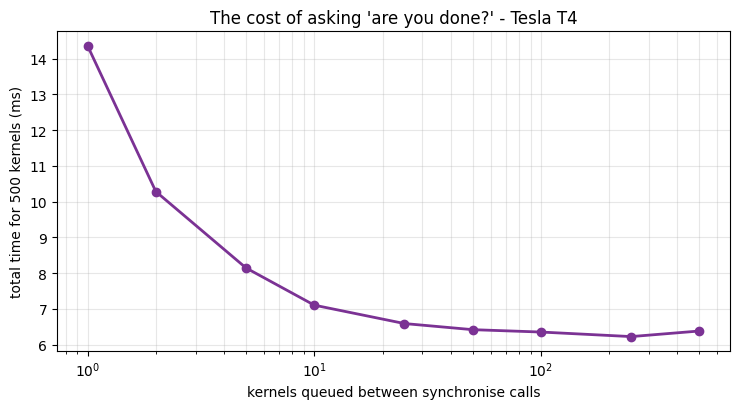

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(intervals, totals, "o-", lw=2, color="#7b3294")
ax.set_xscale("log")
ax.set_xlabel("kernels queued between synchronise calls")
ax.set_ylabel(f"total time for {N_OPS} kernels (ms)")
ax.set_title(f"The cost of asking 'are you done?' - {DEVICE}")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

📝 **Task 3.3 — the fence** *(10 marks)*

- What is the ratio between syncing every op and syncing once at the end?
- The curve flattens. **Why does it stop improving**, and what does the flat level correspond to?
- The lecture's rule is **"never ask the device anything; make the device tell you."** A synchronise here is *not* an MMIO read of a GPU register — explain what it actually polls, and why the naive design (polling a device register over PCIe) would be catastrophic. Use the lecture's cost figures.

*Your answer:*

Syncing every operation gives **28.7 µs/op**, while syncing once at the end gives **12.8 µs/op**. Therefore:

$$
\frac{28.7}{12.8} \approx 2.24\times
$$

So, syncing every operation is about **2.24× more expensive per operation**.

The curve flattens because synchronization overhead is being **amortised** over more queued kernels. After enough kernels are queued between synchronise calls, the synchronization cost becomes small compared with the actual execution and submission costs. The flat level of about **12.7–12.8 µs/op** represents the approximate cost per operation when the fence is no longer being paid after every kernel.

`torch.cuda.synchronize()` does not repeatedly read a GPU register. The GPU writes a **completion/fence value into host DRAM using DMA**, and the CPU checks that value in its own memory. The lecture gives the approximate cost of checking a cached memory value as **~1 ns**.

Polling a GPU status register through PCIe would be much more expensive because an MMIO read is a **non-posted, synchronous PCIe transaction costing about 1–2 µs**. A million such polls could therefore take about a second of CPU time. This is why the design uses a fence value in host memory instead of repeatedly asking the GPU whether it has finished.

---
## Part 4 — The data plane: pinned memory and overlap *(20 marks)*

The control plane is small and expensive. The data plane is bulk and cheap per byte — *provided* the DMA engine can read your buffer where it lies.

A DMA engine has no MMU and cannot take a page fault, so its target pages must be **pinned**. A copy out of ordinary pageable memory therefore secretly performs `CPU memcpy → driver-owned pinned staging buffer → DMA`: a full extra copy you never wrote.

!!! note
    On **Apple silicon** the CPU and GPU share one physical memory pool, so there is no PCIe crossing and no staging copy to remove. Pinning is not exposed, and this section reports the transfer curve only. Say so in your answer — *why* the concept does not apply is itself the answer.

### 🔮 Predict first — Task 4.1

📝 **Before running**: will pinned memory help more at *small* or *large* transfer sizes? Will the advantage grow, shrink, or stay flat with size? Commit to a shape. (On Apple silicon, predict what a unified-memory machine should show instead.)

*Your prediction:*

Pinned memory should provide a greater benefit for **large transfer sizes**. For small transfers, the fixed overheads of starting the transfer are likely to dominate, so the difference between pinned and pageable memory should be relatively small.

As the transfer size increases, pageable memory requires an additional **CPU memcpy to a pinned staging buffer** before the DMA transfer. Therefore, I expect the advantage of pinned memory to **increase with transfer size** and then possibly level off when the DMA or PCIe bandwidth becomes the main limitation.

This prediction does not apply to Apple silicon because the CPU and GPU share the same physical memory pool, so there is no PCIe transfer or staging copy that pinning could remove.

In [19]:
sizes_mb = SIZES_MB
bw_page, bw_pin = [], []

for mb in sizes_mb:
    n = mb * 1024 * 1024 // 4
    pageable = torch.empty(n, dtype=torch.float32)
    dst      = torch.empty(n, dtype=torch.float32, device=DEV)
    gb = n * 4 / 1e9
    bw_page.append(gb / (wall_time_ms(lambda: dst.copy_(pageable), iters=10, warmup=3) * 1e-3))
    if CAPS["pinned"]:
        pinned = torch.empty(n, dtype=torch.float32, pin_memory=True)
        bw_pin.append(gb / (wall_time_ms(lambda: dst.copy_(pinned), iters=10, warmup=3) * 1e-3))
        del pinned
    del pageable, dst
    empty_cache()

if CAPS["pinned"]:
    print(f"{'size':>8}{'pageable GB/s':>16}{'pinned GB/s':>14}{'speedup':>10}")
    print("-" * 48)
    for mb, pg, pn in zip(sizes_mb, bw_page, bw_pin):
        print(f"{mb:>6} MB{pg:>16.2f}{pn:>14.2f}{pn / pg:>9.2f}x")
else:
    print("pinned memory not available on this backend - pageable curve only")
    print(f"{'size':>8}{'GB/s':>12}")
    print("-" * 20)
    for mb, pg in zip(sizes_mb, bw_page):
        print(f"{mb:>6} MB{pg:>12.2f}")

RESULTS["results"]["transfer"] = {
    "sizes_mb": list(sizes_mb), "bw_pageable_gbs": bw_page,
    "bw_pinned_gbs": bw_pin or None,
    "skipped": None if CAPS["pinned"] else "pin_memory unsupported on this backend",
}

    size   pageable GB/s   pinned GB/s   speedup
------------------------------------------------
     1 MB            3.27         10.37     3.17x
     4 MB            5.81         10.79     1.86x
    16 MB            5.79         12.02     2.08x
    64 MB            6.82         12.22     1.79x
   256 MB            6.14         12.30     2.00x


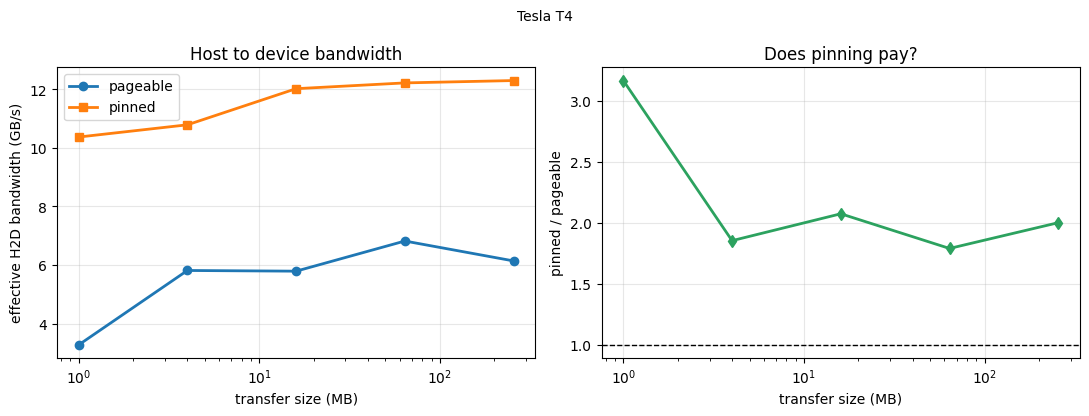

In [20]:
ncols = 2 if CAPS["pinned"] else 1
fig, axes = plt.subplots(1, ncols, figsize=(11 if ncols == 2 else 6, 4.2), squeeze=False)
ax1 = axes[0][0]
ax1.plot(sizes_mb, bw_page, "o-", lw=2, label="pageable")
if CAPS["pinned"]:
    ax1.plot(sizes_mb, bw_pin, "s-", lw=2, label="pinned")
ax1.set_xscale("log"); ax1.set_xlabel("transfer size (MB)")
ax1.set_ylabel("effective H2D bandwidth (GB/s)")
ax1.set_title("Host to device bandwidth"); ax1.grid(alpha=0.3); ax1.legend()
if CAPS["pinned"]:
    ax2 = axes[0][1]
    ax2.plot(sizes_mb, [pn / pg for pg, pn in zip(bw_page, bw_pin)], "d-", lw=2, color="#2ca25f")
    ax2.axhline(1.0, ls="--", c="k", lw=1)
    ax2.set_xscale("log"); ax2.set_xlabel("transfer size (MB)")
    ax2.set_ylabel("pinned / pageable"); ax2.set_title("Does pinning pay?")
    ax2.grid(alpha=0.3)
fig.suptitle(f"{DEVICE}", fontsize=10)
plt.tight_layout(); plt.show()

📝 **Task 4.2 — explain the curve** *(10 marks)*

- Report your bandwidth curve(s) and the speedup shape.
- The lecture deliberately **refuses to quote a speedup number** for pinning, saying it depends on hardware and transfer size. Explain the shape you got in terms of the staging copy: at which sizes does that extra `memcpy` dominate, and at which does something else become the bottleneck?
- **If your speedup is near 1.0× at large sizes, that is a real result, not a failed experiment.** Propose a mechanism, and an experiment that would confirm it.
- If pinning was unavailable on your machine: what does that tell you about its memory architecture, and which lecture concept stops applying?

*Your answer:*

The measured host-to-device bandwidth was:

| Transfer size | Pageable | Pinned | Speedup |
|---:|---:|---:|---:|
| 1 MB | 3.27 GB/s | 10.37 GB/s | 3.17× |
| 4 MB | 5.81 GB/s | 10.79 GB/s | 1.86× |
| 16 MB | 5.79 GB/s | 12.02 GB/s | 2.08× |
| 64 MB | 6.82 GB/s | 12.22 GB/s | 1.79× |
| 256 MB | 6.14 GB/s | 12.30 GB/s | 2.00× |

Pinning gives the largest relative benefit at **1 MB**, where the pageable transfer reaches only 3.27 GB/s compared with 10.37 GB/s for pinned memory. At this size, the extra **CPU memcpy to the driver-owned pinned staging buffer** is a significant part of the transfer time.

For larger transfers, the speedup settles around **1.8–2.1×** rather than continuing to increase. The pinned bandwidth reaches about **12.3 GB/s**, suggesting that the DMA/host-to-device transfer path becomes the main bottleneck. The pageable transfer remains lower because it still has the additional staging-copy step before the DMA transfer.

A speedup close to 1× at large sizes was **not observed on this Tesla T4**. If it occurred, one possible explanation would be that the DMA/PCIe transfer itself had become the dominant bottleneck, making the staging-copy cost relatively insignificant. This could be tested by measuring the transfer bandwidth for progressively larger sizes and checking whether pageable and pinned memory converge toward the same bandwidth.

Pinning was available on this machine, so the Apple-silicon/unified-memory case does not apply.

### Overlap: separate queues run at the same time

Copy engines are separate hardware queues from compute units. Ordering is guaranteed only *within* a stream — so two streams can be in flight simultaneously. This is the mechanism behind prefetching batch *n+1* while computing batch *n*.

📝 **Predict first — Task 4.3**: if a copy takes `C` ms and a matmul takes `M` ms, what should "both, two streams" cost under perfect overlap? What should "both, one stream" cost?

*Your prediction:*

With **one stream**, the copy and matmul are ordered, so their times should add:

$$
T_{\text{one stream}} \approx C + M
$$

With **two streams**, the copy and computation can execute concurrently because they use separate hardware queues. Under perfect overlap, the total time should be approximately the longer of the two:

$$
T_{\text{two streams}} \approx \max(C,M)
$$

Therefore, two streams should reduce the total time from approximately **C + M** to **max(C, M)** when sufficient overlap is possible.

copy alone        :   10.905 ms
matmul alone      :   31.537 ms
both, one stream  :   40.252 ms
both, two streams :   31.974 ms

ideal overlap = max = 31.537 ms
no overlap    = sum = 42.441 ms


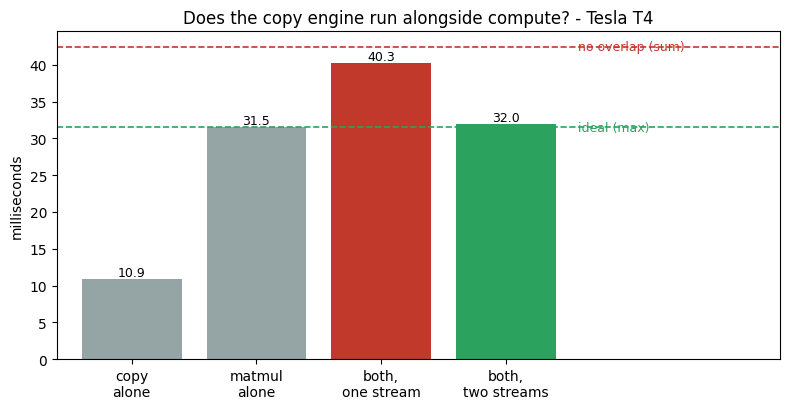

In [21]:
if not CAPS["streams"]:
    print("This backend exposes no command-stream API, so overlap cannot be measured.")
    print("Skipped - not penalised. Answer Task 4.3 from the mechanism instead.")
    RESULTS["results"]["overlap"] = {"skipped": "no stream API on this backend"}
else:
    MB, MM_N = OVERLAP_MB, MATMUL_N
    n = MB * 1024 * 1024 // 4
    src = torch.empty(n, dtype=torch.float32, pin_memory=CAPS["pinned"])
    dst = torch.empty(n, dtype=torch.float32, device=DEV)
    pa  = torch.randn(MM_N, MM_N, device=DEV)
    pb  = torch.randn(MM_N, MM_N, device=DEV)
    copy_stream = torch.cuda.Stream()

    def copy_only():    dst.copy_(src, non_blocking=True)
    def compute_only(): return pa @ pb
    def serial():
        dst.copy_(src, non_blocking=True)
        return pa @ pb
    def overlapped():
        with torch.cuda.stream(copy_stream):
            dst.copy_(src, non_blocking=True)
        c_ = pa @ pb
        torch.cuda.current_stream().wait_stream(copy_stream)
        return c_

    cooldown()
    t_copy = wall_time_ms(copy_only,    iters=10, warmup=3)
    t_comp = wall_time_ms(compute_only, iters=10, warmup=3)
    t_ser  = wall_time_ms(serial,       iters=10, warmup=3)
    t_ovl  = wall_time_ms(overlapped,   iters=10, warmup=3)

    print(f"copy alone        : {t_copy:8.3f} ms")
    print(f"matmul alone      : {t_comp:8.3f} ms")
    print(f"both, one stream  : {t_ser:8.3f} ms")
    print(f"both, two streams : {t_ovl:8.3f} ms")
    print(f"\nideal overlap = max = {max(t_copy, t_comp):.3f} ms")
    print(f"no overlap    = sum = {t_copy + t_comp:.3f} ms")

    RESULTS["results"]["overlap"] = {
        "mb": MB, "matmul_n": MM_N, "copy_ms": t_copy, "compute_ms": t_comp,
        "serial_ms": t_ser, "overlap_ms": t_ovl}

    fig, ax = plt.subplots(figsize=(8, 4.2))
    names = ["copy\nalone", "matmul\nalone", "both,\none stream", "both,\ntwo streams"]
    vals = [t_copy, t_comp, t_ser, t_ovl]
    ax.bar(names, vals, color=["#95a5a6", "#95a5a6", "#c0392b", "#2ca25f"])
    ax.axhline(t_copy + t_comp, ls="--", c="#c0392b", lw=1.2)
    ax.axhline(max(t_copy, t_comp), ls="--", c="#2ca25f", lw=1.2)
    ax.text(3.55, t_copy + t_comp, " no overlap (sum)", va="center", fontsize=9, color="#c0392b")
    ax.text(3.55, max(t_copy, t_comp), " ideal (max)", va="center", fontsize=9, color="#2ca25f")
    ax.set_ylabel("milliseconds"); ax.set_xlim(-0.6, 5.2)
    ax.set_title(f"Does the copy engine run alongside compute? - {DEVICE}")
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

📝 **Task 4.3 — overlap** *(10 marks)*

- How close did two streams get to the ideal `max(copy, compute)`?
- **Why does the one-stream version not overlap at all**, even with `non_blocking=True` on the copy? Answer in terms of what a stream *is*.
- The lecture says `pin_memory=True` and `non_blocking=True` "are one mechanism, not two independent optimizations." Using your Part 4.2 and 4.3 results, justify that claim.
- *If this section was skipped on your backend:* explain what hardware feature is missing and why the lecture's prefetch-the-next-batch pattern cannot be expressed without it.

*Your answer:*
### Task 4.3 — Overlap

The ideal overlap time is **31.537 ms**, while the measured two-stream time is **31.974 ms**. The difference is only:

**31.974 − 31.537 = 0.437 ms**

Therefore, the two-stream result was about **1.4% slower than the ideal**, showing that the copy and computation overlapped very closely.

The one-stream version does not overlap because a stream is an **ordered GPU work queue**. Operations submitted to the same stream execute in order. Therefore, the copy must finish before the matmul starts. `non_blocking=True` allows the CPU to continue without waiting for the copy, but it does not remove the ordering between operations in the same stream.

`pin_memory=True` and `non_blocking=True` work together. Pinning makes the host memory suitable for direct DMA, while `non_blocking=True` allows the copy to be submitted asynchronously. Part 4.2 showed that pinned memory approximately doubled the transfer bandwidth for the larger transfers, while Part 4.3 showed that asynchronous copies in separate streams can overlap with computation. Without pinned memory, the extra staging copy can prevent the desired asynchronous DMA behaviour.

The required hardware feature for this overlap is a **separate copy engine/queue** that can operate alongside the compute engine. Without it, copying and computation could not be executed concurrently, so the prefetch-next-batch-while-computing-current-batch pattern would not be possible.

---
## Part 5 — Amortising submission with CUDA Graphs *(5 marks, bonus-weighted)*

A graph replay is the limit case of the whole lecture: the command packets are built **once**, so replaying them costs the CPU almost nothing.

> ⚠️ **The most backend-dependent code in the lab.** The robust result is the **CPU** column — submission cost collapses everywhere it works. The **GPU** column is not guaranteed to improve, and on some drivers it gets *worse* for many tiny nodes. Apple's Metal backend has no graph capture at all. If it is skipped or raises, say so and move on: an honest surprising measurement earns full marks.

In [22]:
if not CAPS["graphs"]:
    print("No graph-capture API on this backend - skipped, not penalised.")
    RESULTS["results"]["graph"] = {"skipped": "no graph capture on this backend"}
else:
    N_OPS = 100 if SAFE_MODE else 200
    y = torch.zeros(1024, device=DEV)

    def eager():
        for _ in range(N_OPS):
            y.add_(1.0)

    cooldown()
    t_eager_gpu = gpu_time_ms(eager, iters=50, warmup=5)
    t_eager_cpu = wall_time_ms(eager, iters=50, warmup=5, sync_after=False)

    ok, t_graph_gpu, t_graph_cpu = True, None, None
    try:
        g = torch.cuda.CUDAGraph()
        side = torch.cuda.Stream()
        side.wait_stream(torch.cuda.current_stream())
        with torch.cuda.stream(side):      # warm up on a side stream before capture
            eager()
        torch.cuda.current_stream().wait_stream(side)
        sync()
        with torch.cuda.graph(g):
            eager()
        t_graph_gpu = gpu_time_ms(g.replay, iters=50, warmup=5)
        t_graph_cpu = wall_time_ms(g.replay, iters=50, warmup=5, sync_after=False)
    except Exception as e:
        ok = False
        print(f"graph capture unavailable: {type(e).__name__}: {e}")

    print(f"{'method':<28}{'GPU ms':>10}{'CPU ms':>10}{'CPU us/op':>12}")
    print("-" * 60)
    print(f"{'eager (one launch per op)':<28}{t_eager_gpu:>10.3f}{t_eager_cpu:>10.3f}"
          f"{t_eager_cpu / N_OPS * 1e3:>12.2f}")
    if ok:
        print(f"{'graph replay':<28}{t_graph_gpu:>10.3f}{t_graph_cpu:>10.3f}"
              f"{t_graph_cpu / N_OPS * 1e3:>12.2f}")
        print(f"\nCPU submission cost cut {t_eager_cpu / t_graph_cpu:.1f}x")
        if t_graph_gpu > t_eager_gpu:
            print(f"NOTE: GPU-side replay is {t_graph_gpu / t_eager_gpu:.1f}x SLOWER here.")
            print("A driver/runtime property, not a law. Explain it in your answer.")

    RESULTS["results"]["graph"] = {
        "n_ops": N_OPS, "captured": ok,
        "eager_gpu_ms": t_eager_gpu, "eager_cpu_ms": t_eager_cpu,
        "graph_gpu_ms": t_graph_gpu, "graph_cpu_ms": t_graph_cpu}

method                          GPU ms    CPU ms   CPU us/op
------------------------------------------------------------
eager (one launch per op)        5.890     2.825       14.13
graph replay                     0.582     0.107        0.54

CPU submission cost cut 26.3x


📝 **Task 5.1 — graphs** *(5 marks)*

- By what factor did graph replay reduce the **CPU** submission cost? Relate that to your Part 3 measurement of per-submission cost.
- What exactly is *not* being done on a replay that *is* being done on each eager launch?
- If your GPU-side time did not improve (or got worse, or the section was skipped), say so and propose why. Under what circumstances is a graph worth using?

*Your answer:*

Graph replay reduced the CPU submission cost from **14.13 µs/op** to **0.54 µs/op**:

$$
\frac{14.13}{0.54} \approx 26.3\times
$$

This is consistent with the **8.85 µs per-submission cost** measured in Part 3. In eager execution, each operation requires a separate submission to the GPU. With graph replay, the command sequence is captured once, so the repeated CPU-side submission work is largely removed.

On each eager launch, the CPU has to prepare and submit the command through the **ring buffer and doorbell protocol**. During graph replay, these command packets have already been prepared, so the CPU does not need to rebuild and submit each operation separately.

The GPU-side time also improved in this measurement, from **5.890 ms** to **0.582 ms**. However, GPU-side improvement is not guaranteed because graph replay mainly reduces **CPU submission overhead**. A graph is most useful when there are many repeated GPU operations or small kernels where launch/submission overhead is a significant part of the total execution time.

---
## Part 6 — Synthesis *(10 marks)*

📝 **Task 6.1 — place every term**

Lecture 5/6 closes with a two-column board. Fill it in from *your own measurements*, citing the part of this lab where you observed each one.


| Term | Control plane or data plane? | Which measurement showed it? |
|---|---|---|
| Doorbell (MMIO write) | Control plane | Part 2 — unsynchronised timing measured the CPU-side submission process |
| Ring buffer | Control plane | Part 2 — the kernel was queued before GPU execution |
| Fence value | Control plane | Part 2 — `with sync` and CUDA events measured actual completion/execution |
| DMA / bus master | Data plane | Part 4.2 — host-to-device memory transfers |
| Pinning | Data plane | Part 4.2 — pinned memory increased transfer bandwidth |
| Stream | Control plane | Part 4.3 — two streams allowed copy and computation to overlap |

📝 **Task 6.2 — the one-paragraph version**

A colleague reports that their model "runs at 400 TFLOP/s on a T4." In one paragraph, say what you would ask them to check first, what command you would have them run, and what you expect to find. Your Part 1 work should shape this answer.

*Your answer:*

A reported **400 TFLOP/s on a Tesla T4** should first be checked to determine whether the measurement includes actual GPU execution. The T4's FP32 peak is about **8.10 TFLOP/s**, so 400 TFLOP/s is far above the hardware peak. The first check would be `nvidia-smi` to confirm the GPU, followed by repeating the timing with `torch.cuda.synchronize()` or CUDA events. I would expect the unsynchronised measurement to have timed only CPU-side submission through the ring buffer and doorbell rather than the actual GPU execution, producing an artificially high throughput.
📝 **Task 6.3 — your summary**

Your machine, your headline numbers, and the single most surprising result with your explanation.

*Your answer:*

My machine was a **Tesla T4** with **15.64 GB VRAM**. The FP32 peak was **8.10 TFLOP/s**, while my measured FP32 performance was **3.36 TFLOP/s**.

The most surprising result was the unsynchronised matmul measurement of **5484.8 TFLOP/s**, which was about **677× the vendor peak**. This happened because the timer measured **CPU-side submission of the GPU work rather than its actual execution**. With synchronisation, the measured throughput was only **3.1 TFLOP/s**.

---
## Part 7 — Export your submission *(required)*

Two short-answer cells, then the export. The numeric answers below are checked automatically; the prose in your 📝 cells is read from the notebook itself, so **submit both files**.

In [25]:
ANSWERS = {
    # Part 1
    "peak_vendor_tflops":     8.10,
    "peak_measured_tflops":   3.36,
    "peak_efficiency":        0.415,

    # Part 2
    "nosync_over_peak":       677.1,

    # Part 3
    "launch_bound_elements":  1048576,
    "fence_penalty_ratio":    2.25,

    # Part 4
    "pinning_helps_below_mb": 1,
    "overlap_efficiency":     1.33,

    # Part 5
    "graph_cpu_speedup":      26.3,
}

for k, v in ANSWERS.items():
    print(f"  {k:<26} {v}")
missing = [k for k, v in ANSWERS.items() if v is None]
print(f"\n{len(ANSWERS) - len(missing)}/{len(ANSWERS)} filled"
      + (f"  |  still None: {missing}" if missing else "  |  complete"))
print("\nNone is legitimate for anything your backend skipped - the grader knows.")

  peak_vendor_tflops         8.1
  peak_measured_tflops       3.36
  peak_efficiency            0.415
  nosync_over_peak           677.1
  launch_bound_elements      1048576
  fence_penalty_ratio        2.25
  pinning_helps_below_mb     1
  overlap_efficiency         1.33
  graph_cpu_speedup          26.3

9/9 filled  |  complete

None is legitimate for anything your backend skipped - the grader knows.


In [26]:
# Export. Writes submission_<roll>.json next to the notebook.
import hashlib

assert ROLL_NUMBER, "Set ROLL_NUMBER in the Part 0 setup cell."

RESULTS["answers"] = ANSWERS
RESULTS["student"] = {"roll": str(ROLL_NUMBER).strip(), "name": str(NAME).strip()}
RESULTS["env"]["exported_utc"] = datetime.now(timezone.utc).isoformat(timespec="seconds")

payload = json.dumps(RESULTS, indent=2, sort_keys=True, default=str)
RESULTS["integrity"] = {"sha256": hashlib.sha256(payload.encode()).hexdigest()[:16]}

fname = f"submission_{RESULTS['student']['roll']}.json"
with open(fname, "w") as f:
    json.dump(RESULTS, f, indent=2, sort_keys=True, default=str)

done = sorted(RESULTS["results"])
skipped = [k for k, v in RESULTS["results"].items() if isinstance(v, dict) and v.get("skipped")]
print(f"wrote {fname}")
print(f"experiments recorded: {len(done)} -> {', '.join(done)}")
if skipped:
    print(f"skipped on this backend (not penalised): {', '.join(skipped)}")
print(f"integrity digest    : {RESULTS['integrity']['sha256']}")
if len(done) < 8:
    print("\nWARNING: some experiments are missing. Run every cell top to bottom.")

try:
    from google.colab import files  # noqa
    files.download(fname)
except Exception:
    pass

wrote submission_202518035.json
experiments recorded: 8 -> fence, graph, launch, overlap, peak, submission, sweep, transfer
integrity digest    : 6de3e9ba91281bad


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Submit both:**

1. `submission_<roll>.json` — the file just written
2. this notebook, executed, saved with outputs intact (`File > Download > .ipynb`)

The JSON carries your measurements; the notebook carries your reasoning. A JSON without its notebook cannot be marked, and a notebook whose stored outputs disagree with its JSON will be flagged.

---
## Marks

Marks fall into two halves, and they are assessed differently.

**Automatic — 40 marks.** Checked by script from your exported JSON.

| ID | What is checked | Marks |
|---|---|---:|
| A1 | Provenance: device, backend, declared peak, your roll number | 4 |
| A2 | All experiments recorded (skipped-by-backend counts as recorded) | 3 |
| A3 | Unsynchronised timer at least 10× faster than synchronised | 4 |
| A4 | Implied no-sync throughput exceeds your declared peak | 4 |
| A5 | Synchronised and event timings agree within 15% | 4 |
| A6 | Launch-bound signature present in the size sweep | 4 |
| A7 | Syncing every op costs at least 1.5× syncing once | 4 |
| A8 | Two streams beat one stream | 4 |
| A9 | Per-launch submission cost lands in 1–20 µs | 2 |
| A10 | Your short answers are consistent with your own recorded numbers | 3 |
| A11 | Peak established on every route your hardware allows, and measured ≤ vendor | 4 |

These check **relationships between your own numbers**, never their magnitudes against a reference — your hardware is yours.

Four things are deliberately **not** auto-checked, because the honest answer varies: whether pinning helps at large sizes, whether CUDA Graphs improve GPU-side time, whether overlap is observable when copy and compute are unbalanced, and anything your backend cannot do at all. Reporting "no benefit" or "unavailable" costs you nothing.

**Rubric — 60 marks.** Your written 📝 cells, read from the notebook.

Predictions are marked for being *made*, not for being right. Explanations are marked on whether they name the mechanism: ring, doorbell, fence, DMA, pinning, stream. A number without a mechanism scores roughly half. A mechanism that contradicts your own data scores less than an honest "I measured X, I expected Y, here is my best explanation for the gap."

**Integrity.** Timing floats carry several digits of run-to-run noise, so two independent runs never produce identical values. Submissions sharing a measurement vector are treated as copied.

**Reproducibility.** State your GPU, host, PyTorch version and backend. On Colab, say which accelerator you were assigned — it varies between sessions and changes every number here.

---
## References

1. [Lecture 5/6 — GPU Job Submission](../lectures/Lecture5_6.md) — the mechanism this lab measures
2. [Lecture 7 — Inside the GPU](../lectures/Lecture7.md) — how peak FLOP/s is built from lanes, clocks and FMAs
3. NVIDIA, [*CUDA C++ Best Practices Guide*](https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/) — asynchronous transfers, streams, CUDA Graphs
4. PyTorch, [CUDA semantics](https://docs.pytorch.org/docs/stable/notes/cuda.html) · [MPS backend](https://docs.pytorch.org/docs/stable/notes/mps.html)
5. [TechPowerUp GPU database](https://www.techpowerup.com/gpu-specs/) — per-model FP32 figures, listed separately from tensor-core and sparsity numbers
6. Course code: [`code/gpu_submission`](https://github.com/Ankush-Chander/DS635-ml-system-engineering/tree/main/code/gpu_submission)